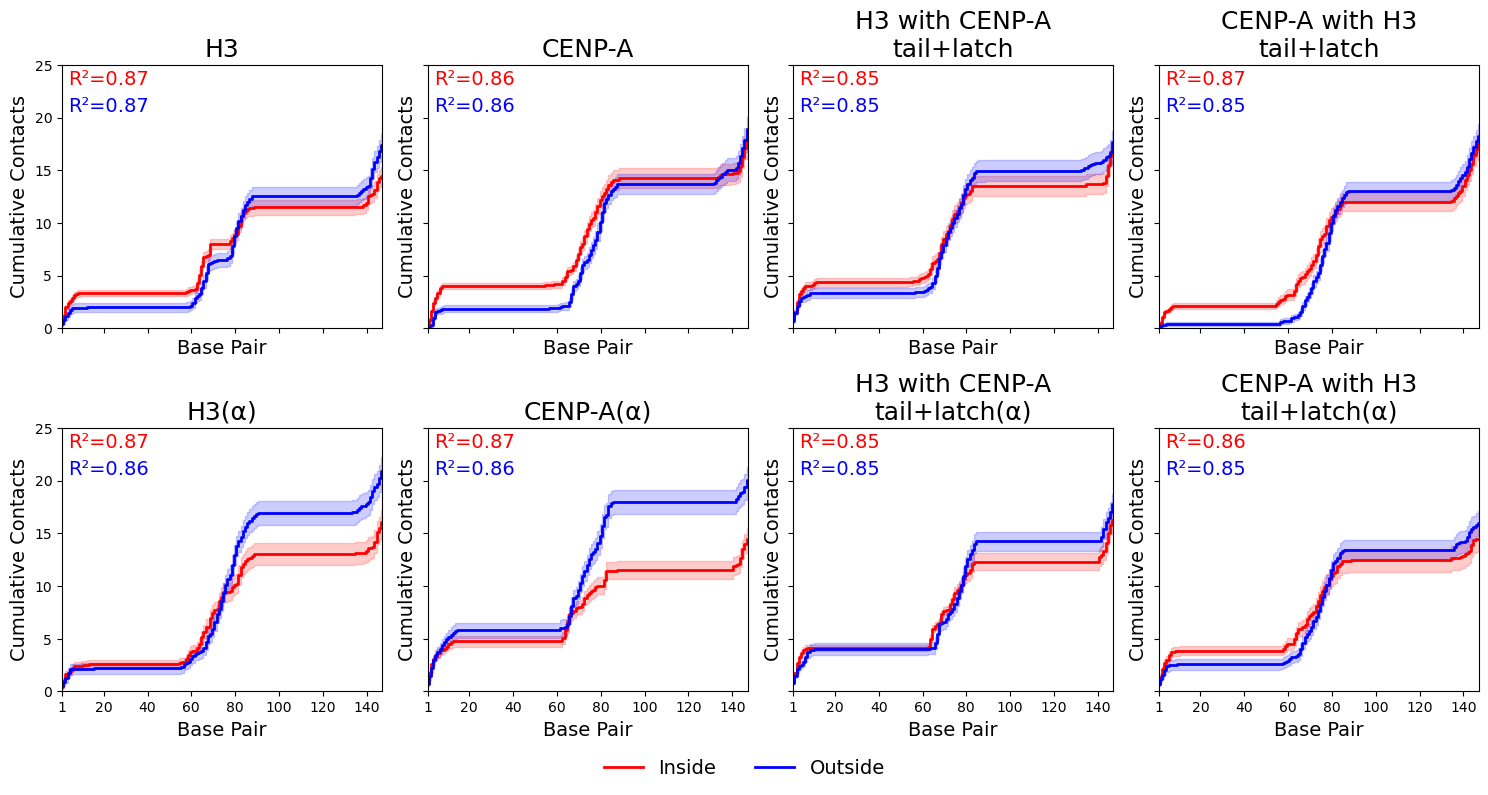

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import os

systems = [
    "H3", "cenpa", "ltH3core", "ltcenpacore",
    "CSH3", "CScenpa", "CSltH3core", "CSltcenpacore"
]

titles = {
    "H3": "H3",
    "cenpa": "CENP-A",
    "ltH3core": "H3 with CENP-A\ntail+latch",
    "ltcenpacore": "CENP-A with H3\ntail+latch",
    "CSH3": "H3(\u03B1)",
    "CScenpa": "CENP-A(\u03B1)",
    "CSltH3core": "H3 with CENP-A\ntail+latch(\u03B1)",
    "CSltcenpacore": "CENP-A with H3\ntail+latch(\u03B1)"
}

fig, axes = plt.subplots(2,4, figsize=(15,8), sharex=True, sharey=True)
axes = axes.flatten()

bp_labels = [1,20,40,60,80,100,120,140]

for idx, system in enumerate(systems):

    ax = axes[idx]

    if system is None:
        ax.axis('off')
        continue

    data = np.loadtxt(os.path.join(system,f"{system}_tail_contacts_inside_outside_freq_SEM.dat"),skiprows=1)

    inside = data[:,1]
    inside_sem = data[:,2]
    outside = data[:,3]
    outside_sem = data[:,4]

    n_bps = 147

    cumulative_inside = np.zeros(n_bps)
    cumulative_inside_sem = np.zeros(n_bps)
    cumulative_outside = np.zeros(n_bps)
    cumulative_outside_sem = np.zeros(n_bps)

    total_inside = 0
    total_inside_var = 0
    total_outside = 0
    total_outside_var = 0

    for j in range(n_bps):

        base1 = j
        base2 = 294 - j - 1

        pair_inside = inside[base1] + inside[base2]
        pair_outside = outside[base1] + outside[base2]

        pair_inside_sem = np.sqrt(inside_sem[base1]**2 + inside_sem[base2]**2)
        pair_outside_sem = np.sqrt(outside_sem[base1]**2 + outside_sem[base2]**2)

        total_inside += pair_inside
        total_inside_var += pair_inside_sem**2

        total_outside += pair_outside
        total_outside_var += pair_outside_sem**2

        cumulative_inside[j] = total_inside
        cumulative_inside_sem[j] = np.sqrt(total_inside_var)

        cumulative_outside[j] = total_outside
        cumulative_outside_sem[j] = np.sqrt(total_outside_var)

    x = np.arange(1,n_bps+1)

    # plot
    ax.step(x, cumulative_inside, where='mid', color='red', lw=2, label="Inside")
    ax.fill_between(
        x,
        cumulative_inside-cumulative_inside_sem,
        cumulative_inside+cumulative_inside_sem,
        step='mid',
        color='red',
        alpha=0.2
    )

    ax.step(x, cumulative_outside, where='mid', color='blue', lw=2, label="Outside")
    ax.fill_between(
        x,
        cumulative_outside-cumulative_outside_sem,
        cumulative_outside+cumulative_outside_sem,
        step='mid',
        color='blue',
        alpha=0.2
    )

    # ----------------
    # R² calculation
    # ----------------

    fit_inside = np.polyfit(x,cumulative_inside,1)
    pred_inside = np.polyval(fit_inside,x)

    ss_res = np.sum((cumulative_inside - pred_inside)**2)
    ss_tot = np.sum((cumulative_inside - np.mean(cumulative_inside))**2)
    r2_inside = 1 - ss_res/ss_tot


    fit_outside = np.polyfit(x,cumulative_outside,1)
    pred_outside = np.polyval(fit_outside,x)

    ss_res = np.sum((cumulative_outside - pred_outside)**2)
    ss_tot = np.sum((cumulative_outside - np.mean(cumulative_outside))**2)
    r2_outside = 1 - ss_res/ss_tot

    # ----------------
    # Place labels INSIDE subplot
    # ----------------

    ax.text(
        0.02, 0.98,
        f"R²={r2_inside:.2f}",
        color="red",
        fontsize=14,
        ha='left',
        va='top',
        transform=ax.transAxes
    )

    ax.text(
        0.02, 0.88,
        f"R²={r2_outside:.2f}",
        color="blue",
        fontsize=14,
        ha='left',
        va='top',
        transform=ax.transAxes
    )

    ax.set_title(titles[system], fontsize=18)
    ax.set_xticks(bp_labels)
    ax.set_xlim(1,147)
    ax.set_ylim(0,25)
    ax.set_xlabel("Base Pair", fontsize=14)
    ax.set_ylabel("Cumulative Contacts", fontsize=14)

# ----------------
# Bottom legend
# ----------------

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=14, frameon=False)

plt.tight_layout(rect=[0,0.05,1,1])
plt.show()